In [1]:
import keras
import numpy as np
from keras.applications import mobilenet
from keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array
from keras.models import load_model
import matplotlib.pyplot as plt



In [2]:
def predict_snake(image_path):
    model = load_model('mobilenet-ft.model')

    # Load and preprocess the image
    original = load_img(image_path, target_size=(224, 224))
    numpy_image = img_to_array(original)
    image_batch = np.expand_dims(numpy_image, axis=0)
    processed_image = mobilenet.preprocess_input(image_batch.copy())

    # Make predictions
    predictions = model.predict(processed_image)
    print('Raw Predictions:', predictions)

    # Decode predictions (get the class labels)
    class_list = ["cobra", "common_krait", "hump_nosed_pit_viper", "Python", "Rat_snake", "russells_viper", "Saw_Scaled_Viper"]
    decoded_predictions = decode_predictions_specific(predictions, top=1, class_list=class_list)
    print('Decoded Predictions:', decoded_predictions) 

    # Display the image
    plt.imshow(original)
    plt.show()




In [18]:

    model = load_model('mobilenet-ft.model')

    # Print model summary to find the last convolutional layer name
    model.summary()

    # ... rest of the code


Model: "model_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_10 (InputLayer)       [(None, 224, 224, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 112, 112, 32)      864       
                                                                 
 conv1_bn (BatchNormalizati  (None, 112, 112, 32)      128       
 on)                                                             
                                                                 
 conv1_relu (ReLU)           (None, 112, 112, 32)      0         
                                                                 
 conv_dw_1 (DepthwiseConv2D  (None, 112, 112, 32)      288       
 )                                                               
                                                                 
 conv_dw_1_bn (BatchNormali  (None, 112, 112, 32)      128 

 )                                                               
                                                                 
 conv_dw_8_bn (BatchNormali  (None, 14, 14, 512)       2048      
 zation)                                                         
                                                                 
 conv_dw_8_relu (ReLU)       (None, 14, 14, 512)       0         
                                                                 
 conv_pw_8 (Conv2D)          (None, 14, 14, 512)       262144    
                                                                 
 conv_pw_8_bn (BatchNormali  (None, 14, 14, 512)       2048      
 zation)                                                         
                                                                 
 conv_pw_8_relu (ReLU)       (None, 14, 14, 512)       0         
                                                                 
 conv_dw_9 (DepthwiseConv2D  (None, 14, 14, 512)       4608      
 )        




1/1 [==============================] - 1s 760ms/step
Raw Predictions: [[0.6391515  0.29560667 0.00264737 0.03829476 0.0242996 ]]
Decoded Predictions: [[('cobra', 0.6391515)]]


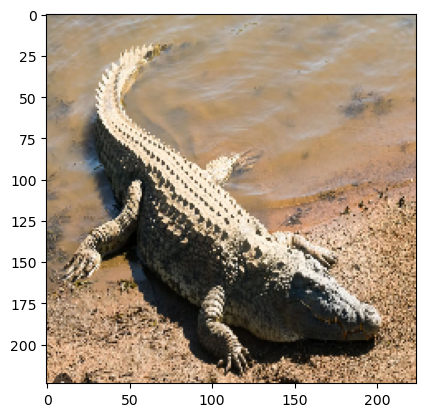

In [3]:
def decode_predictions_specific(preds, top=1, class_list=None):
    results = []
    for pred in preds:
        top_indices = pred.argsort()[-top:][::-1]
        result = [(class_list[i], pred[i]) for i in top_indices]
        results.append(result)
    return results

# Example usage
image_path = "croc.jpg"
predict_snake(image_path)

# with heatmap

In [3]:
import keras
import numpy as np
from keras.applications import mobilenet
from keras.preprocessing.image import load_img, img_to_array
from keras.models import load_model
import matplotlib.pyplot as plt
import tensorflow as tf
import matplotlib.cm as cm
from IPython.display import Image, display


def make_gradcam_heatmap(img_arr, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.input], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_arr)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])

        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)

    return heatmap.numpy()
def save_and_display_gradcam(img_path, heatmap, cam_path="cam.jpg", alpha=0.4):
    img = img_to_array(load_img(img_path))  # Corrected typo
    heatmap = np.uint8(224 * heatmap)
    
    jet = cm.get_cmap("jet", 256)  # Updated line
    jet_colors = jet(np.arange(256))
    jet_heatmap = jet_colors[heatmap]
    
    # Convert jet_heatmap to RGB
    jet_heatmap_rgb = jet_heatmap[:, :, :3]

    # Resize jet_heatmap to match the shape of the original image
    jet_heatmap_rgb = keras.preprocessing.image.array_to_img(jet_heatmap_rgb)
    jet_heatmap_rgb = jet_heatmap_rgb.resize((img.shape[1], img.shape[0]))

    # Convert jet_heatmap_rgb to array
    jet_heatmap_rgb_array = keras.preprocessing.image.img_to_array(jet_heatmap_rgb)

    # Overlay jet_heatmap_rgb on the original image
    superimposed_img = jet_heatmap_rgb_array * alpha + img
    superimposed_img = keras.preprocessing.image.array_to_img(superimposed_img)

    # Save and display the superimposed image
    superimposed_img.save(cam_path)
    display(Image(cam_path))

def predict_snake(image_path):
    model = load_model('mobilenet-ft.model')
    last_conv_layer_name = "conv_pw_13_relu"

    # Load and preprocess the image
    original = load_img(image_path, target_size=(224, 224))
    numpy_image = img_to_array(original)
    image_batch = np.expand_dims(numpy_image, axis=0)
    processed_image = mobilenet.preprocess_input(image_batch.copy())

    # Make predictions
    predictions = model.predict(processed_image)
    print('Raw Predictions:', predictions)

    # Decode predictions (get the class labels)
    class_list = ["cobra", "common_krait", "hump_nosed_pit_viper", "Python", "Rat_snake", "russells_viper", "Saw_Scaled_Viper"]
    decoded_predictions = decode_predictions_specific(predictions, top=1, class_list=class_list)
    print('Decoded Predictions:', decoded_predictions)

    # Display the image
    heatmap = make_gradcam_heatmap(processed_image, model, 'conv_pw_13_relu', pred_index=None)
    plt.title("Heatmap")
    plt.imshow(heatmap)
    plt.imshow(original)
    plt.show()
    save_and_display_gradcam(image_path, heatmap)  # Use image_path here
    a = plt.imread(image_path)
    plt.imshow(a, cmap="gray")

    return model  # Return the loaded model


1/1 [==============================] - 1s 564ms/step
Raw Predictions: [[2.9026583e-04 1.9426534e-03 3.4483403e-03 8.4132349e-01 4.6901692e-05
  1.4617564e-01 6.7726811e-03]]
Decoded Predictions: [[('Python', 0.8413235)]]


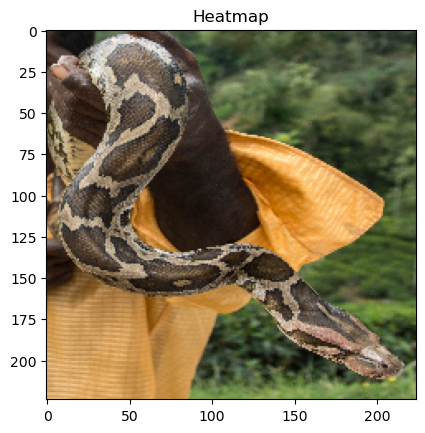

C:\Users\Sandusha\AppData\Local\Temp\ipykernel_17236\1428114624.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  jet = cm.get_cmap("jet", 256)  # Updated line


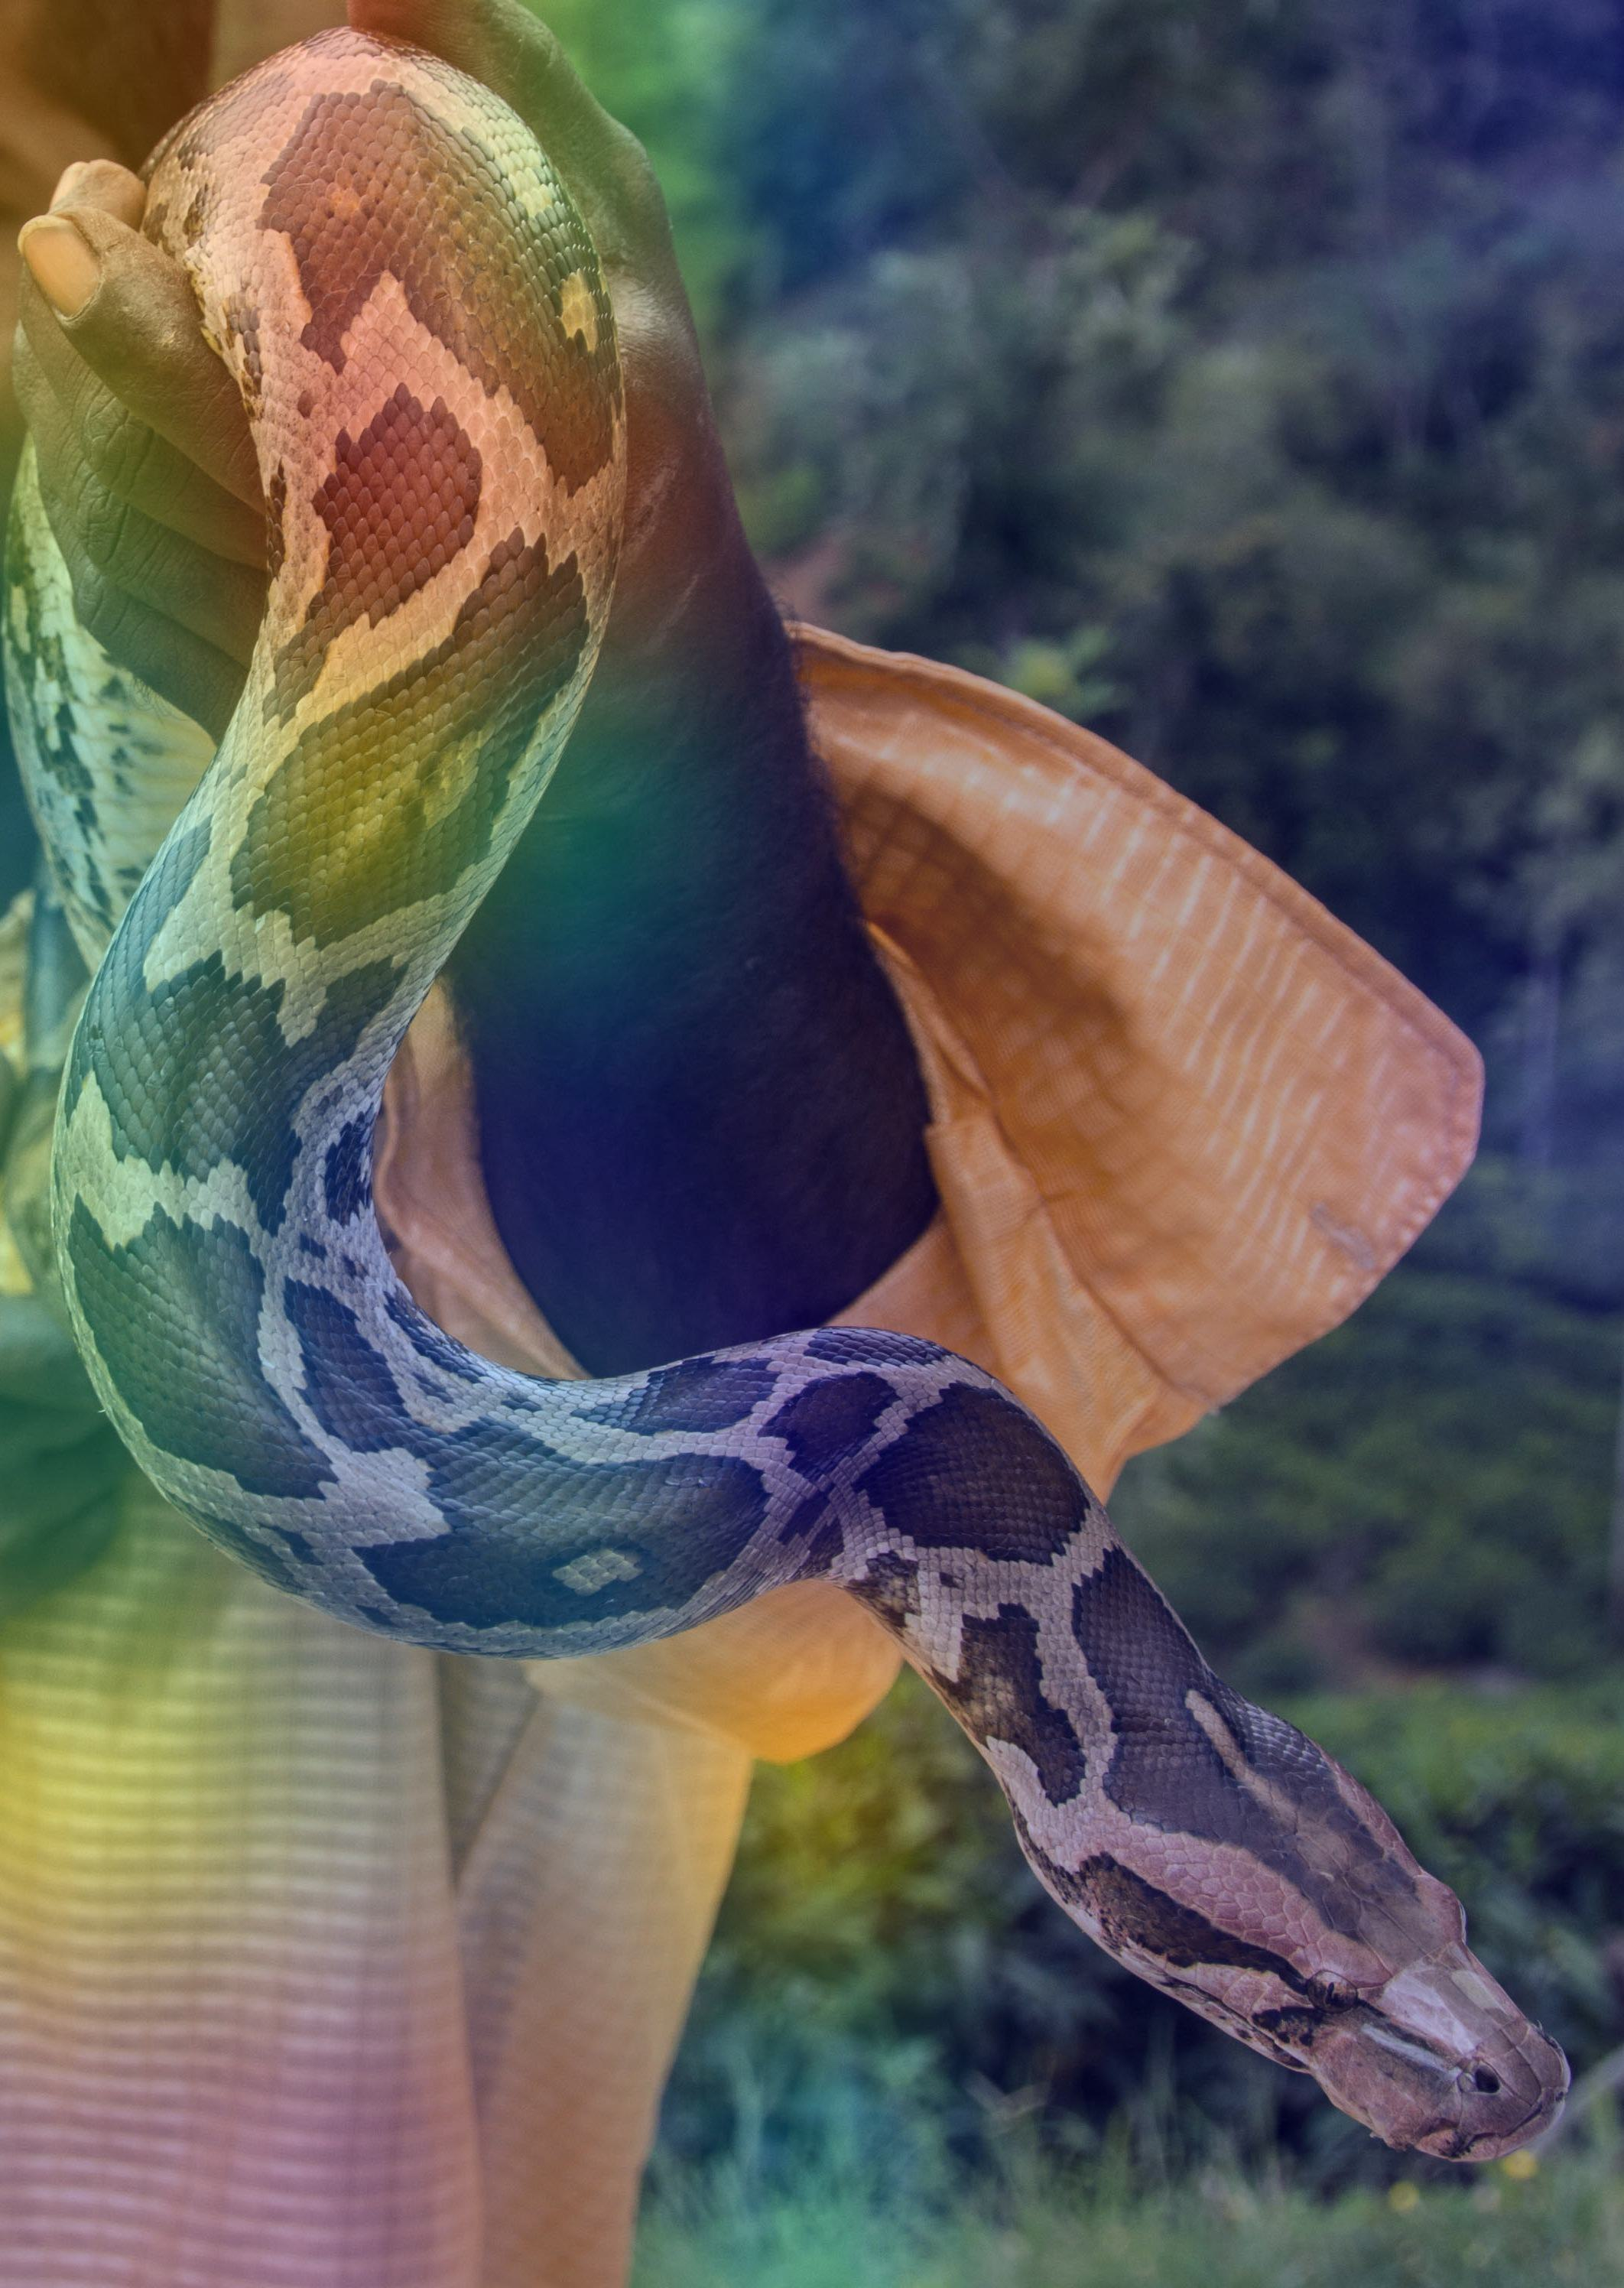

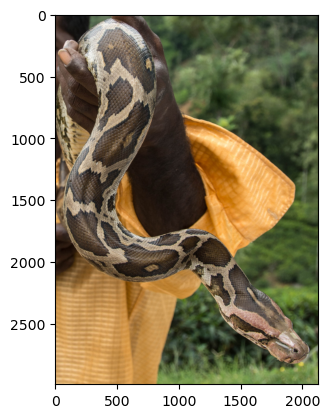

In [13]:
def decode_predictions_specific(preds, top=1, class_list=None):
    results = []
    for pred in preds:
        top_indices = pred.argsort()[-top:][::-1]
        result = [(class_list[i], pred[i]) for i in top_indices]
        results.append(result)
    return results

# Example usage
image_path = "n1.jpg"
loaded_model = predict_snake(image_path)